
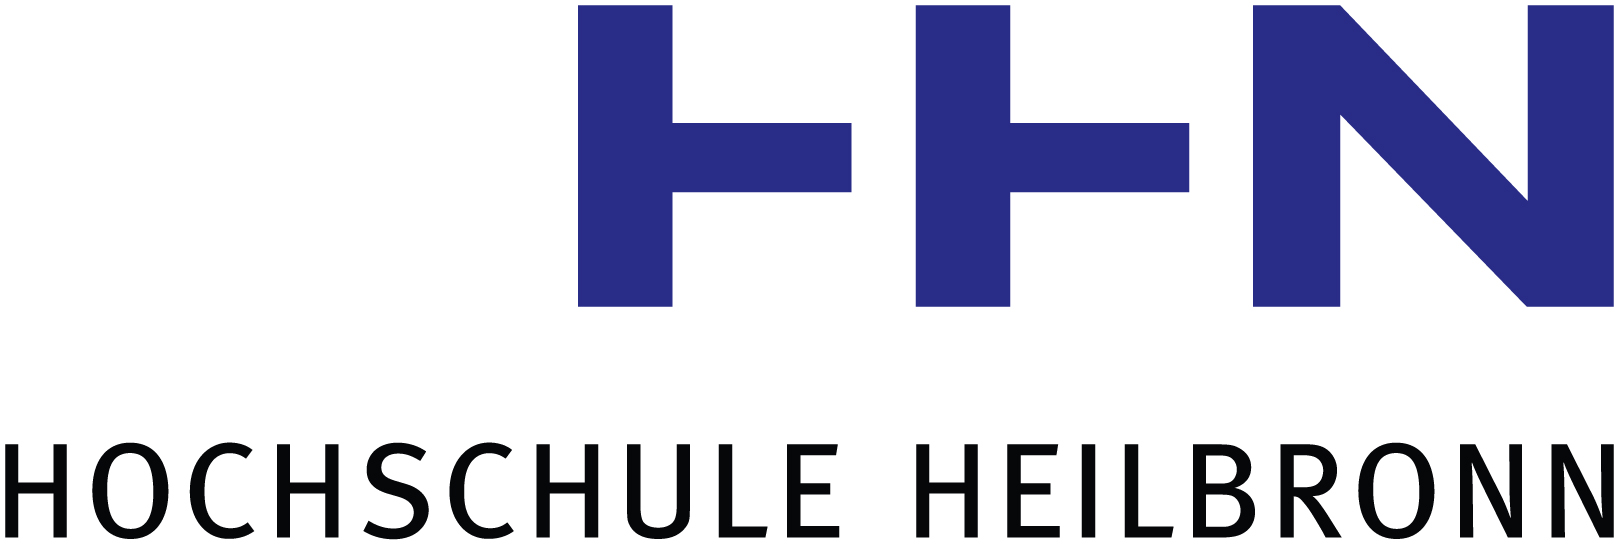


**MWI - Deep Learning**


# RQ1 (Portfolio Examination)

## Overfitting Under Control 
#### *Comparing Regularization Techniques for MLPs*

**Due Date:** April 1, 2026  
**Team:** [Your Team Name]  
**Members:** [Name 1, Name 2]  


---

### Research Question

> *How effectively do different regularization techniques (L2, L1, Dropout, Batch Normalization, Early Stopping) prevent overfitting in MLPs, and at what network size does regularization become necessary?*

---

**How to use this template:**
- This notebook runs **out of the box** and produces a baseline result.
- Look for `# TODO` markers -- these are the places where you need to add your experiments.
- All helper code (data loading, training loop, plotting) is provided.
- Collect all results in the `results` DataFrame for systematic comparison.
- Add Markdown cells to document your observations as you go.

## 1. Setup and Imports

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
import time

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration -- CPU is fine for MNIST MLPs
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

Using device: cuda


## 2. Data Loading and Preparation

We load MNIST and split into **train** (50,000), **validation** (10,000), and **test** (10,000).
- The validation set is used for hyperparameter tuning and monitoring overfitting.
- The test set is used **only once** for the final evaluation.

Training samples:   50000
Validation samples: 10000
Test samples:       10000


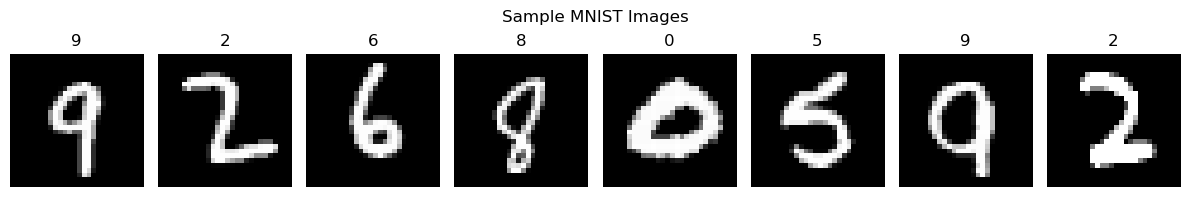

In [26]:
# MNIST normalization: mean=0.1307, std=0.3081 (precomputed for MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download MNIST
full_train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

# Split training set into train (50k) and validation (10k)
train_dataset, val_dataset = random_split(
    full_train_dataset, [50000, 10000],
    generator=torch.Generator().manual_seed(SEED)
)

print(f'Training samples:   {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Test samples:       {len(test_dataset)}')


def get_dataloaders(batch_size=128):
    """Create DataLoaders with the given batch size."""
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


# Quick sanity check: show a few samples
train_loader, val_loader, test_loader = get_dataloaders()
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'{labels[i].item()}')
    ax.axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.show()

## 3. MLP Model Definition

A configurable MLP with adjustable:
- Number of hidden layers (`num_layers`)
- Neurons per layer (`hidden_size`)
- Optional Dropout (`dropout_rate`)
- Optional Batch Normalization (`use_batchnorm`)

In [27]:
class MLP(nn.Module):
    """Configurable Multi-Layer Perceptron for MNIST classification.
    
    Args:
        input_size:    Number of input features (784 for flattened 28x28).
        num_classes:   Number of output classes (10 for MNIST digits).
        hidden_size:   Number of neurons per hidden layer.
        num_layers:    Number of hidden layers.
        dropout_rate:  Dropout probability (0.0 = no dropout).
        use_batchnorm: Whether to add BatchNorm after each hidden layer.
    """
    def __init__(self, input_size=784, num_classes=10, hidden_size=128,
                 num_layers=2, dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        
        layers = []
        in_features = input_size
        
        for i in range(num_layers):
            layers.append(nn.Linear(in_features, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_features = hidden_size
        
        layers.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        # Flatten the 28x28 image into a 784-dim vector
        x = x.view(x.size(0), -1)
        return self.network(x)
    
    def count_parameters(self):
        """Return total number of trainable parameters."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Quick test: create a small model and check it works
test_model = MLP(hidden_size=64, num_layers=1)
test_out = test_model(images)
print(f'Model output shape: {test_out.shape}')  # Should be [batch_size, 10]
print(f'Number of parameters: {test_model.count_parameters():,}')

Model output shape: torch.Size([128, 10])
Number of parameters: 50,890


## 4. Training and Evaluation Functions

The training loop logs loss and accuracy for both training and validation sets at each epoch. This is essential for plotting learning curves and detecting overfitting.

In [28]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=0.0):
    """Train for one epoch. Returns average loss and accuracy.
    
    Args:
        l1_lambda: If > 0, adds L1 regularization to the loss (manual penalty).
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # L1 regularization: manually add sum of absolute weights to loss
        if l1_lambda > 0:
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / total, 100.0 * correct / total


def evaluate(model, data_loader, criterion, device):
    """Evaluate model on a dataset. Returns average loss and accuracy."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / total, 100.0 * correct / total

In [29]:
def train_model(model, train_loader, val_loader, num_epochs=30,
                lr=0.001, weight_decay=0.0, l1_lambda=0.0,
                early_stopping_patience=0, verbose=True):
    """Full training loop with logging and optional early stopping.
    
    Args:
        model:            The MLP model to train.
        train_loader:     DataLoader for training data.
        val_loader:       DataLoader for validation data.
        num_epochs:       Maximum number of training epochs.
        lr:               Learning rate for Adam optimizer.
        weight_decay:     L2 regularization strength (passed to optimizer).
        l1_lambda:        L1 regularization strength (added manually to loss).
        early_stopping_patience: Stop after this many epochs without val improvement.
                                 0 = disabled.
        verbose:          Print progress every 5 epochs.
    
    Returns:
        history: dict with keys 'train_loss', 'val_loss', 'train_acc', 'val_acc'
                 (lists of per-epoch values).
        best_val_acc: Best validation accuracy achieved.
        best_epoch:   Epoch at which best validation accuracy was achieved.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        # Track best validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        
        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f'Epoch {epoch:3d}/{num_epochs} | '
                  f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')
        
        # Early stopping
        if early_stopping_patience > 0 and patience_counter >= early_stopping_patience:
            if verbose:
                print(f'Early stopping at epoch {epoch} (best val acc: {best_val_acc:.2f}% at epoch {best_epoch})')
            break
    
    # Restore best model weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return history, best_val_acc, best_epoch

## 5. Plotting Functions

Ready-to-use visualization functions for learning curves and result comparisons.

In [30]:
def plot_learning_curves(history, title='Learning Curves'):
    """Plot training and validation loss/accuracy curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} -- Loss')
    ax1.legend()
    
    # Accuracy
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    ax2.plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{title} -- Accuracy')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()


def plot_comparison_curves(histories, labels, metric='val_loss', title='Comparison'):
    """Overlay multiple training runs on a single plot.
    
    Args:
        histories: list of history dicts from train_model().
        labels:    list of labels for each run.
        metric:    which metric to plot ('train_loss', 'val_loss', 'train_acc', 'val_acc').
    """
    plt.figure(figsize=(10, 6))
    for history, label in zip(histories, labels):
        epochs = range(1, len(history[metric]) + 1)
        plt.plot(epochs, history[metric], label=label, linewidth=2)
    
    plt.xlabel('Epoch')
    ylabel = 'Loss' if 'loss' in metric else 'Accuracy (%)'
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_results_bar(results_df, metric='test_acc', title='Model Comparison'):
    """Bar chart comparing models on a given metric."""
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(results_df)), results_df[metric], color='steelblue')
    plt.xticks(range(len(results_df)), results_df['experiment'], rotation=45, ha='right')
    plt.ylabel(metric)
    plt.title(title)
    
    # Add value labels on bars
    for bar, val in zip(bars, results_df[metric]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()


def plot_overfitting_heatmap(results_df):
    """Heatmap showing the overfitting gap (train_acc - val_acc) across configurations."""
    if 'overfitting_gap' not in results_df.columns:
        print('Column "overfitting_gap" not found in results. Skipping.')
        return
    
    # Attempt to pivot if num_layers and hidden_size columns exist
    if 'num_layers' in results_df.columns and 'hidden_size' in results_df.columns:
        pivot = results_df.pivot_table(
            values='overfitting_gap', index='num_layers', columns='hidden_size'
        )
        plt.figure(figsize=(8, 5))
        im = plt.imshow(pivot.values, cmap='Reds', aspect='auto')
        plt.colorbar(im, label='Overfitting Gap (%)')
        plt.xticks(range(len(pivot.columns)), pivot.columns)
        plt.yticks(range(len(pivot.index)), pivot.index)
        plt.xlabel('Hidden Size')
        plt.ylabel('Number of Layers')
        plt.title('Overfitting Gap by Network Architecture')
        
        # Annotate cells
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                plt.text(j, i, f'{pivot.values[i, j]:.1f}%',
                         ha='center', va='center', fontsize=11)
        plt.tight_layout()
        plt.show()
    else:
        print('Need "num_layers" and "hidden_size" columns for heatmap.')

## 6. Results Collection

Use this DataFrame to systematically collect all experiment results. Append a row after each experiment.

In [31]:
# Results storage -- append a row for each experiment
results = pd.DataFrame(columns=[
    'experiment',       # descriptive name, e.g. "Baseline 2x128"
    'num_layers',       # number of hidden layers
    'hidden_size',      # neurons per hidden layer
    'regularization',   # technique used, e.g. "None", "L2(1e-3)", "Dropout(0.3)"
    'num_params',       # total trainable parameters
    'best_val_acc',     # best validation accuracy (%)
    'best_epoch',       # epoch of best validation accuracy
    'test_acc',         # final test accuracy (%)
    'train_acc_final',  # training accuracy at end of training
    'overfitting_gap',  # train_acc_final - best_val_acc
])

# Store histories for later plotting
all_histories = {}


def record_result(name, model, history, best_val_acc, best_epoch,
                  num_layers, hidden_size, regularization='None'):
    """Evaluate on test set and record results in the global DataFrame."""
    global results
    
    criterion = nn.CrossEntropyLoss()
    _, test_acc = evaluate(model, test_loader, criterion, device)
    train_acc_final = history['train_acc'][-1]
    gap = train_acc_final - best_val_acc
    
    new_row = pd.DataFrame([{
        'experiment': name,
        'num_layers': num_layers,
        'hidden_size': hidden_size,
        'regularization': regularization,
        'num_params': model.count_parameters(),
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
        'test_acc': test_acc,
        'train_acc_final': train_acc_final,
        'overfitting_gap': gap,
    }])
    results = pd.concat([results, new_row], ignore_index=True)
    all_histories[name] = history
    
    print(f'\n--- {name} ---')
    print(f'Parameters: {model.count_parameters():,}')
    print(f'Best Val Acc: {best_val_acc:.2f}% (epoch {best_epoch})')
    print(f'Test Acc:     {test_acc:.2f}%')
    print(f'Overfit Gap:  {gap:.2f}%')
    return test_acc

---

## 7. Experiment 1: Baseline (No Regularization)

Train MLPs of different sizes **without any regularization** to see when overfitting occurs.

BASELINE: 1 hidden layer, 128 neurons, no regularization
Epoch   1/30 | Train Loss: 0.3253 Acc: 90.64% | Val Loss: 0.2045 Acc: 93.98%
Epoch   5/30 | Train Loss: 0.0613 Acc: 98.13% | Val Loss: 0.0992 Acc: 96.97%
Epoch  10/30 | Train Loss: 0.0234 Acc: 99.33% | Val Loss: 0.0949 Acc: 97.24%
Epoch  15/30 | Train Loss: 0.0107 Acc: 99.70% | Val Loss: 0.1014 Acc: 97.40%
Epoch  20/30 | Train Loss: 0.0054 Acc: 99.86% | Val Loss: 0.1150 Acc: 97.44%
Epoch  25/30 | Train Loss: 0.0062 Acc: 99.80% | Val Loss: 0.1303 Acc: 97.39%
Epoch  30/30 | Train Loss: 0.0038 Acc: 99.88% | Val Loss: 0.1397 Acc: 97.38%

--- Baseline 1x128 ---
Parameters: 101,770
Best Val Acc: 97.59% (epoch 27)
Test Acc:     97.82%
Overfit Gap:  2.29%


C:\Users\nils1\AppData\Local\Temp\ipykernel_28304\1250173931.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)


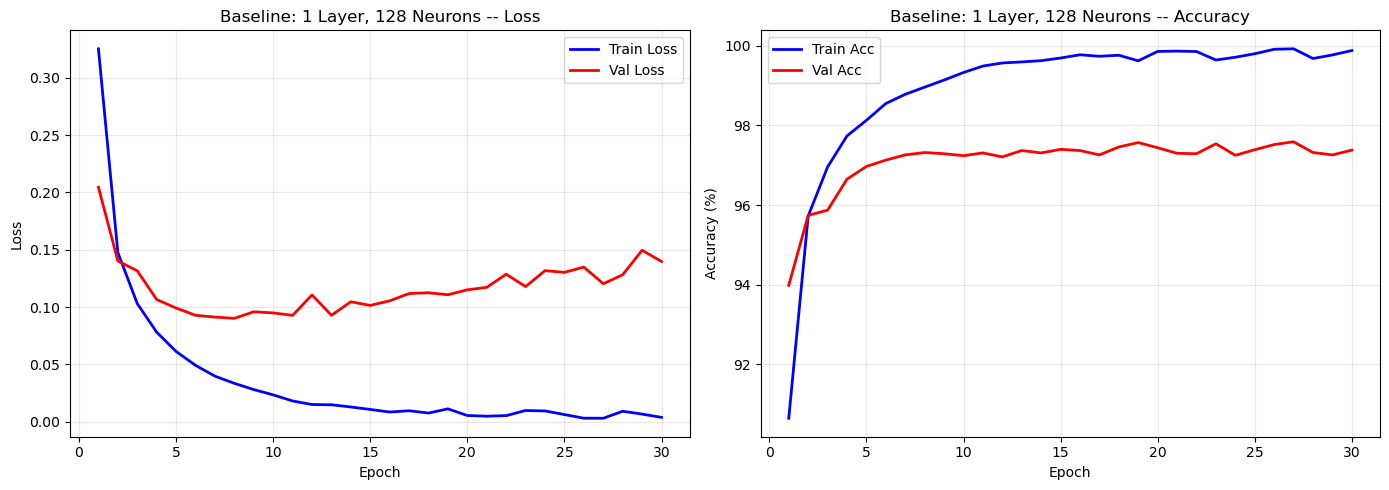

In [32]:
# Baseline: a small MLP (1 layer, 128 neurons) -- runs quickly as a sanity check
print('=' * 60)
print('BASELINE: 1 hidden layer, 128 neurons, no regularization')
print('=' * 60)

model_baseline = MLP(hidden_size=128, num_layers=1)
history_baseline, best_val, best_ep = train_model(
    model_baseline, train_loader, val_loader, num_epochs=30
)

record_result('Baseline 1x128', model_baseline, history_baseline,
              best_val, best_ep, num_layers=1, hidden_size=128)

plot_learning_curves(history_baseline, title='Baseline: 1 Layer, 128 Neurons')

Epoch   1/30 | Train Loss: 0.3739 Acc: 89.41% | Val Loss: 0.2340 Acc: 93.19%
Epoch   5/30 | Train Loss: 0.0869 Acc: 97.44% | Val Loss: 0.1225 Acc: 96.55%
Epoch  10/30 | Train Loss: 0.0409 Acc: 98.74% | Val Loss: 0.1021 Acc: 97.03%
Epoch  15/30 | Train Loss: 0.0191 Acc: 99.47% | Val Loss: 0.1057 Acc: 97.10%
Epoch  20/30 | Train Loss: 0.0109 Acc: 99.70% | Val Loss: 0.1149 Acc: 97.25%
Epoch  25/30 | Train Loss: 0.0071 Acc: 99.81% | Val Loss: 0.1298 Acc: 97.13%
Epoch  30/30 | Train Loss: 0.0120 Acc: 99.58% | Val Loss: 0.1511 Acc: 97.20%

--- Baseline 1x64 ---
Parameters: 50,890
Best Val Acc: 97.32% (epoch 11)
Test Acc:     97.58%
Overfit Gap:  2.26%


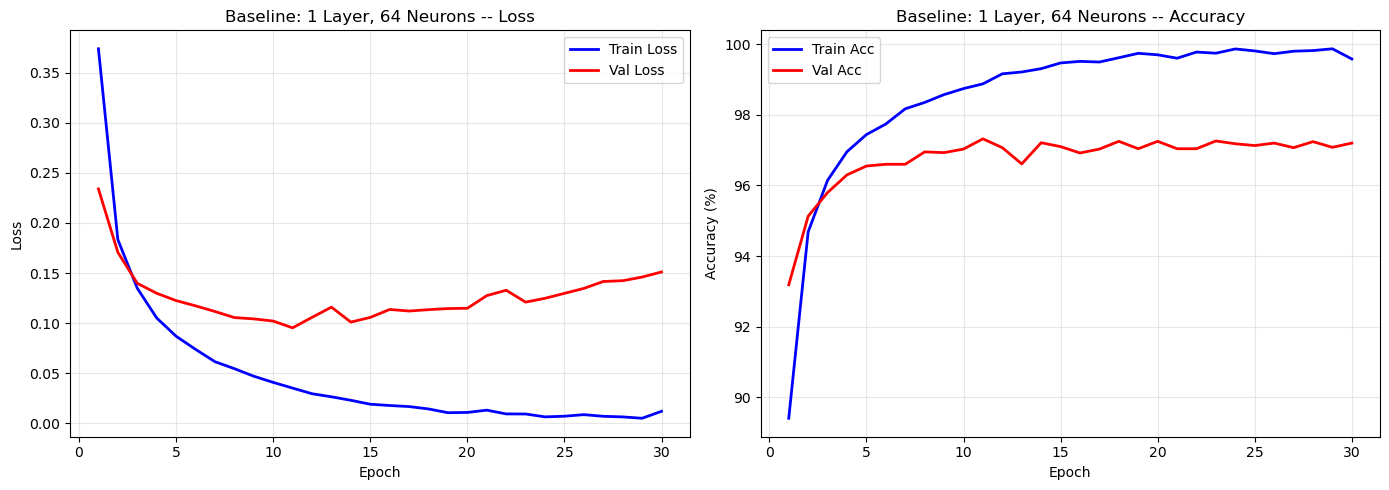

Epoch   1/30 | Train Loss: 0.3959 Acc: 88.70% | Val Loss: 0.2317 Acc: 92.97%
Epoch   5/30 | Train Loss: 0.0817 Acc: 97.53% | Val Loss: 0.1167 Acc: 96.50%
Epoch  10/30 | Train Loss: 0.0386 Acc: 98.81% | Val Loss: 0.1354 Acc: 96.31%
Epoch  15/30 | Train Loss: 0.0208 Acc: 99.37% | Val Loss: 0.1276 Acc: 96.84%
Epoch  20/30 | Train Loss: 0.0170 Acc: 99.40% | Val Loss: 0.1493 Acc: 96.89%
Epoch  25/30 | Train Loss: 0.0100 Acc: 99.65% | Val Loss: 0.1529 Acc: 96.98%
Epoch  30/30 | Train Loss: 0.0086 Acc: 99.73% | Val Loss: 0.1574 Acc: 97.18%

--- Baseline 2x64 ---
Parameters: 55,050
Best Val Acc: 97.32% (epoch 28)
Test Acc:     97.68%
Overfit Gap:  2.41%


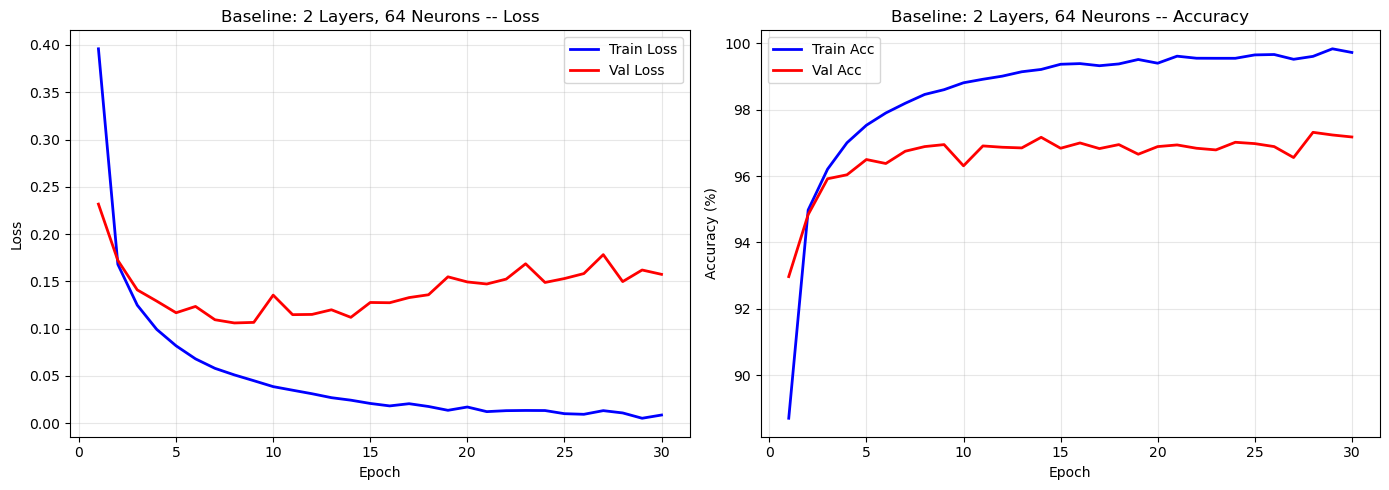

Epoch   1/30 | Train Loss: 0.4216 Acc: 87.42% | Val Loss: 0.2280 Acc: 93.11%
Epoch   5/30 | Train Loss: 0.0832 Acc: 97.40% | Val Loss: 0.1223 Acc: 96.36%
Epoch  10/30 | Train Loss: 0.0404 Acc: 98.66% | Val Loss: 0.1098 Acc: 97.11%
Epoch  15/30 | Train Loss: 0.0225 Acc: 99.25% | Val Loss: 0.1214 Acc: 97.24%
Epoch  20/30 | Train Loss: 0.0200 Acc: 99.32% | Val Loss: 0.1481 Acc: 96.84%
Epoch  25/30 | Train Loss: 0.0120 Acc: 99.60% | Val Loss: 0.1687 Acc: 96.87%
Epoch  30/30 | Train Loss: 0.0108 Acc: 99.62% | Val Loss: 0.1715 Acc: 97.19%

--- Baseline 3x64 ---
Parameters: 59,210
Best Val Acc: 97.54% (epoch 24)
Test Acc:     97.80%
Overfit Gap:  2.08%


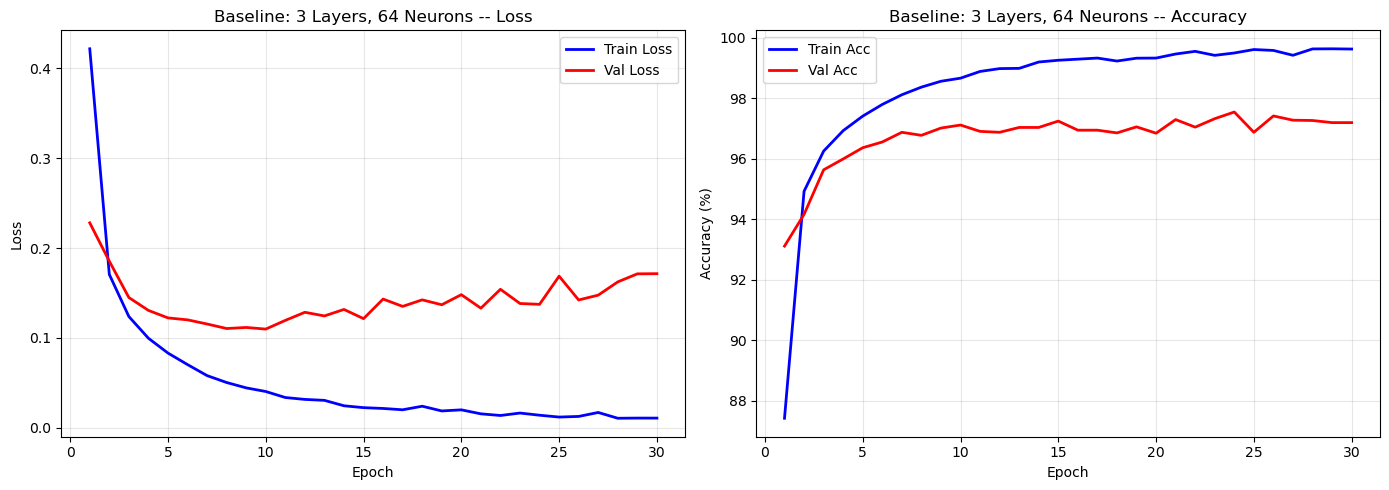

Epoch   1/30 | Train Loss: 0.4710 Acc: 85.12% | Val Loss: 0.2411 Acc: 92.75%
Epoch   5/30 | Train Loss: 0.0876 Acc: 97.29% | Val Loss: 0.1343 Acc: 95.98%
Epoch  10/30 | Train Loss: 0.0431 Acc: 98.53% | Val Loss: 0.1125 Acc: 96.81%
Epoch  15/30 | Train Loss: 0.0283 Acc: 99.01% | Val Loss: 0.1322 Acc: 96.95%
Epoch  20/30 | Train Loss: 0.0217 Acc: 99.23% | Val Loss: 0.1453 Acc: 97.08%
Epoch  25/30 | Train Loss: 0.0155 Acc: 99.53% | Val Loss: 0.1546 Acc: 96.81%
Epoch  30/30 | Train Loss: 0.0117 Acc: 99.61% | Val Loss: 0.1632 Acc: 96.94%

--- Baseline 4x64 ---
Parameters: 63,370
Best Val Acc: 97.22% (epoch 22)
Test Acc:     97.40%
Overfit Gap:  2.39%


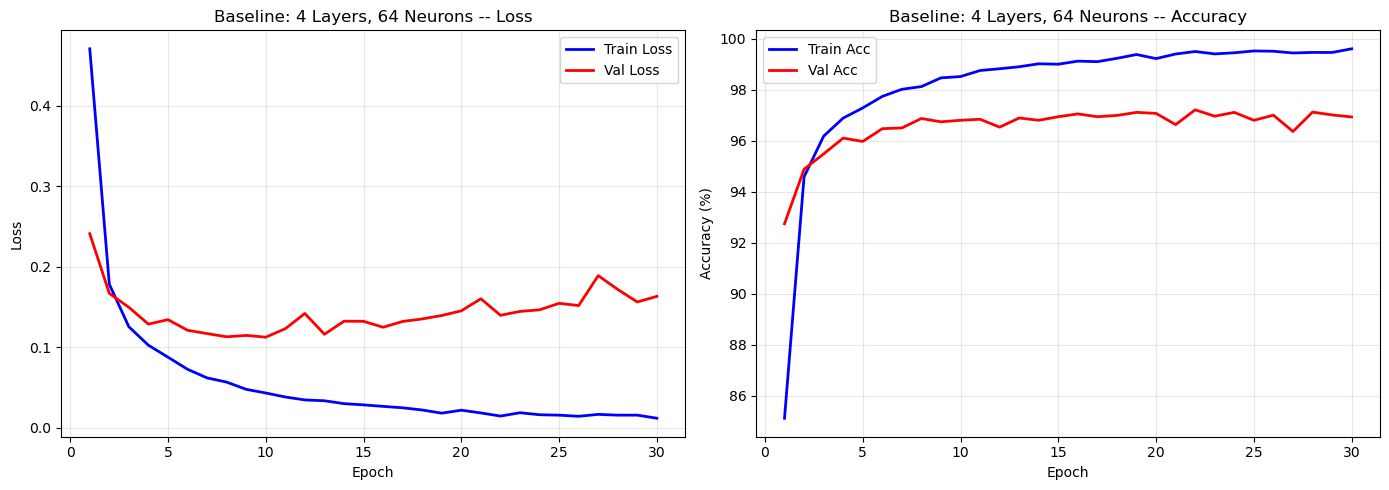

Epoch   1/30 | Train Loss: 0.5558 Acc: 81.84% | Val Loss: 0.2558 Acc: 92.35%
Epoch   5/30 | Train Loss: 0.0904 Acc: 97.20% | Val Loss: 0.1333 Acc: 96.01%
Epoch  10/30 | Train Loss: 0.0450 Acc: 98.54% | Val Loss: 0.1322 Acc: 96.42%
Epoch  15/30 | Train Loss: 0.0308 Acc: 98.92% | Val Loss: 0.1378 Acc: 96.55%
Epoch  20/30 | Train Loss: 0.0184 Acc: 99.41% | Val Loss: 0.1504 Acc: 97.05%
Epoch  25/30 | Train Loss: 0.0162 Acc: 99.45% | Val Loss: 0.1631 Acc: 96.99%
Epoch  30/30 | Train Loss: 0.0125 Acc: 99.59% | Val Loss: 0.1650 Acc: 96.97%

--- Baseline 5x64 ---
Parameters: 67,530
Best Val Acc: 97.20% (epoch 24)
Test Acc:     97.25%
Overfit Gap:  2.39%


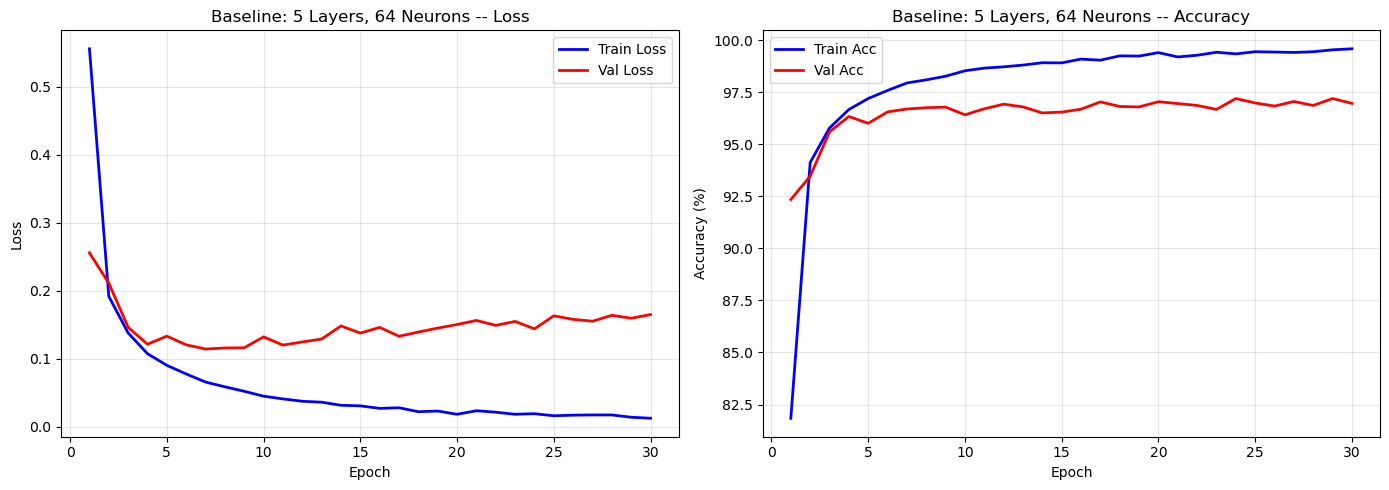

Epoch   1/30 | Train Loss: 0.2833 Acc: 91.76% | Val Loss: 0.1794 Acc: 94.52%
Epoch   5/30 | Train Loss: 0.0448 Acc: 98.64% | Val Loss: 0.0914 Acc: 97.18%
Epoch  10/30 | Train Loss: 0.0125 Acc: 99.64% | Val Loss: 0.0829 Acc: 97.73%
Epoch  15/30 | Train Loss: 0.0081 Acc: 99.74% | Val Loss: 0.1229 Acc: 97.37%
Epoch  20/30 | Train Loss: 0.0144 Acc: 99.53% | Val Loss: 0.1167 Acc: 97.69%
Epoch  25/30 | Train Loss: 0.0009 Acc: 99.99% | Val Loss: 0.1119 Acc: 97.81%
Epoch  30/30 | Train Loss: 0.0020 Acc: 99.94% | Val Loss: 0.1351 Acc: 97.62%

--- Baseline 1x256 ---
Parameters: 203,530
Best Val Acc: 97.88% (epoch 26)
Test Acc:     98.14%
Overfit Gap:  2.06%


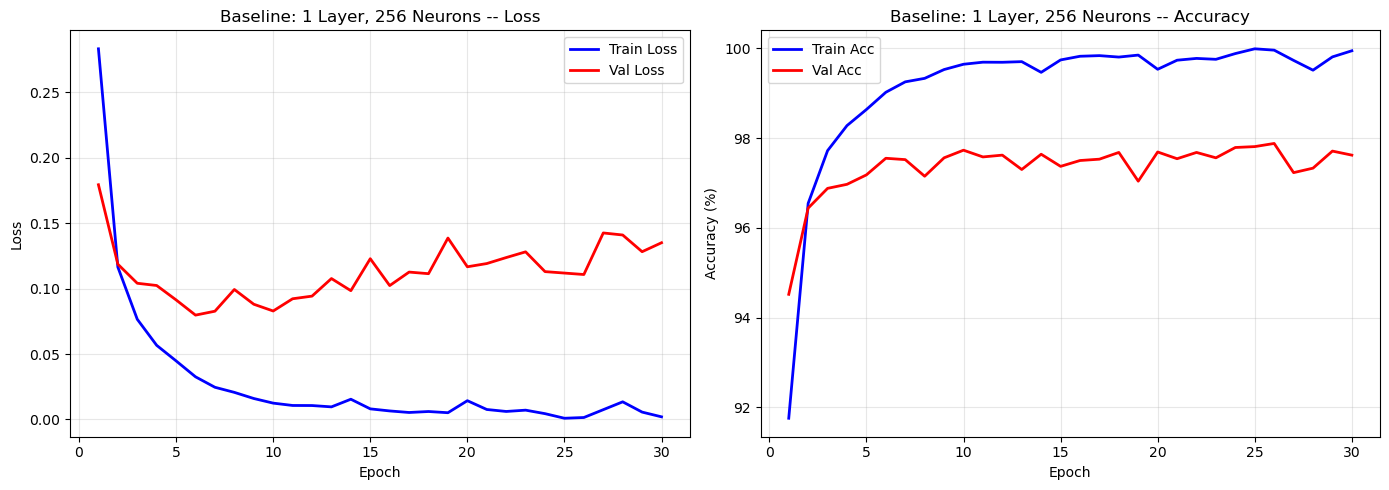

Epoch   1/30 | Train Loss: 0.2802 Acc: 91.75% | Val Loss: 0.1453 Acc: 95.58%
Epoch   5/30 | Train Loss: 0.0388 Acc: 98.71% | Val Loss: 0.0891 Acc: 97.49%
Epoch  10/30 | Train Loss: 0.0139 Acc: 99.53% | Val Loss: 0.1120 Acc: 97.66%
Epoch  15/30 | Train Loss: 0.0133 Acc: 99.58% | Val Loss: 0.1150 Acc: 97.56%
Epoch  20/30 | Train Loss: 0.0082 Acc: 99.74% | Val Loss: 0.1305 Acc: 97.47%
Epoch  25/30 | Train Loss: 0.0115 Acc: 99.63% | Val Loss: 0.1691 Acc: 97.48%
Epoch  30/30 | Train Loss: 0.0106 Acc: 99.68% | Val Loss: 0.1403 Acc: 97.74%

--- Baseline 2x256 ---
Parameters: 269,322
Best Val Acc: 97.91% (epoch 23)
Test Acc:     97.89%
Overfit Gap:  1.77%


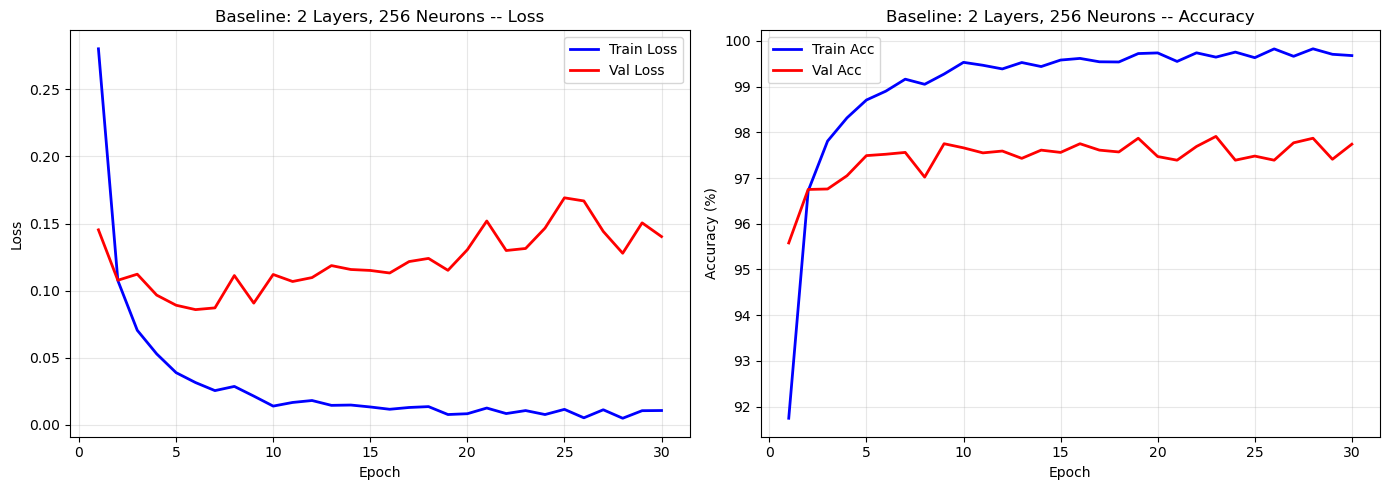

Epoch   1/30 | Train Loss: 0.2847 Acc: 91.55% | Val Loss: 0.1439 Acc: 95.65%
Epoch   5/30 | Train Loss: 0.0489 Acc: 98.42% | Val Loss: 0.0953 Acc: 97.55%
Epoch  10/30 | Train Loss: 0.0217 Acc: 99.26% | Val Loss: 0.1093 Acc: 97.51%
Epoch  15/30 | Train Loss: 0.0170 Acc: 99.48% | Val Loss: 0.0988 Acc: 97.83%
Epoch  20/30 | Train Loss: 0.0106 Acc: 99.65% | Val Loss: 0.1180 Acc: 97.87%
Epoch  25/30 | Train Loss: 0.0090 Acc: 99.73% | Val Loss: 0.1404 Acc: 97.63%
Epoch  30/30 | Train Loss: 0.0114 Acc: 99.66% | Val Loss: 0.1307 Acc: 97.53%

--- Baseline 3x256 ---
Parameters: 335,114
Best Val Acc: 97.89% (epoch 27)
Test Acc:     98.20%
Overfit Gap:  1.77%


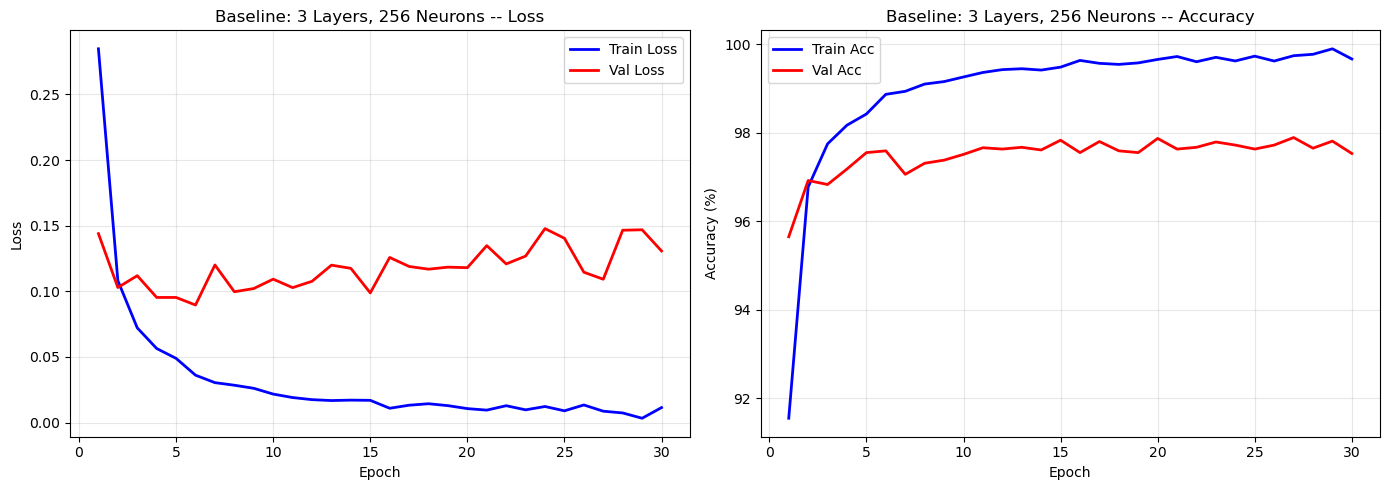

Epoch   1/30 | Train Loss: 0.3094 Acc: 90.63% | Val Loss: 0.1417 Acc: 95.49%
Epoch   5/30 | Train Loss: 0.0491 Acc: 98.48% | Val Loss: 0.1001 Acc: 97.19%
Epoch  10/30 | Train Loss: 0.0266 Acc: 99.21% | Val Loss: 0.0990 Acc: 97.72%
Epoch  15/30 | Train Loss: 0.0176 Acc: 99.50% | Val Loss: 0.1189 Acc: 97.68%
Epoch  20/30 | Train Loss: 0.0127 Acc: 99.56% | Val Loss: 0.1424 Acc: 97.61%
Epoch  25/30 | Train Loss: 0.0116 Acc: 99.68% | Val Loss: 0.1186 Acc: 97.84%
Epoch  30/30 | Train Loss: 0.0128 Acc: 99.67% | Val Loss: 0.1205 Acc: 97.82%

--- Baseline 4x256 ---
Parameters: 400,906
Best Val Acc: 97.84% (epoch 25)
Test Acc:     98.10%
Overfit Gap:  1.83%


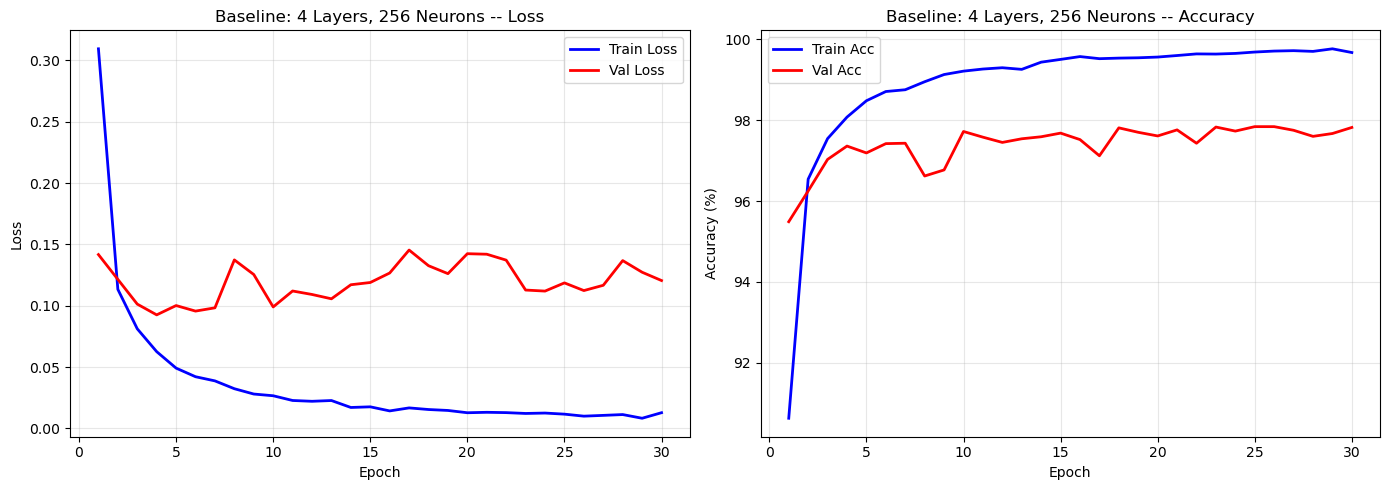

Epoch   1/30 | Train Loss: 0.3380 Acc: 89.57% | Val Loss: 0.1600 Acc: 95.17%
Epoch   5/30 | Train Loss: 0.0558 Acc: 98.28% | Val Loss: 0.1046 Acc: 97.32%
Epoch  10/30 | Train Loss: 0.0335 Acc: 99.00% | Val Loss: 0.0931 Acc: 97.66%
Epoch  15/30 | Train Loss: 0.0182 Acc: 99.46% | Val Loss: 0.1167 Acc: 97.72%
Epoch  20/30 | Train Loss: 0.0143 Acc: 99.60% | Val Loss: 0.1122 Acc: 97.84%
Epoch  25/30 | Train Loss: 0.0105 Acc: 99.71% | Val Loss: 0.1275 Acc: 97.96%
Epoch  30/30 | Train Loss: 0.0125 Acc: 99.67% | Val Loss: 0.1883 Acc: 97.88%

--- Baseline 5x256 ---
Parameters: 466,698
Best Val Acc: 97.96% (epoch 25)
Test Acc:     98.16%
Overfit Gap:  1.71%


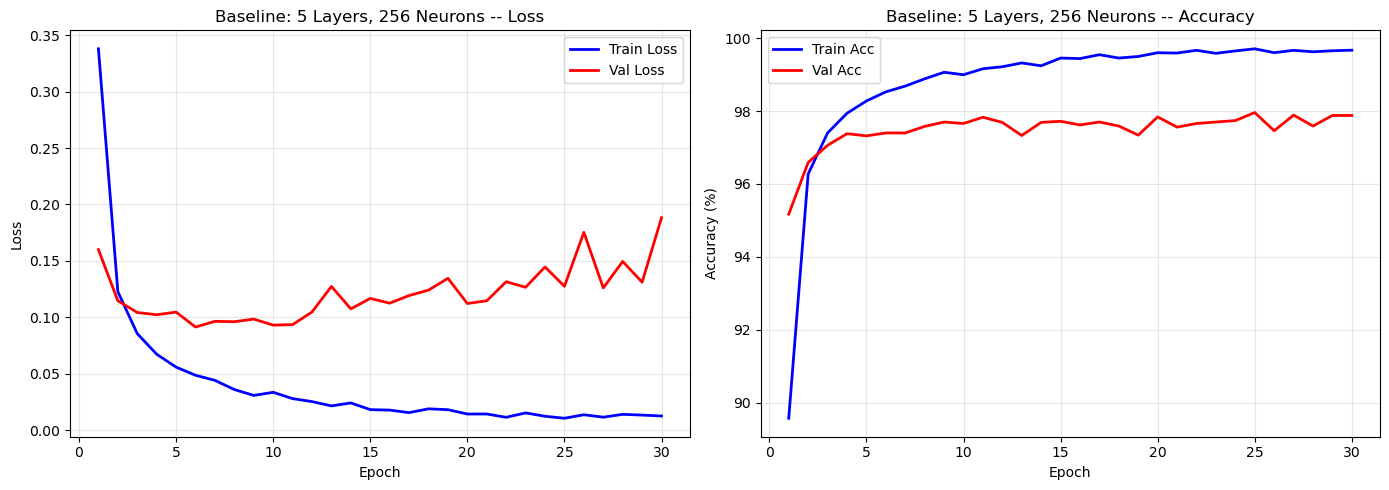

In [ ]:
# TODO: Extend the baseline experiment.
# Train MLPs with different architectures WITHOUT regularization:
#   - Vary num_layers: 1, 2, 3, 4
#   - Vary hidden_size: 64, 128, 256, 512
#   - You don't need to test every combination -- pick a meaningful subset
#     (e.g., fix hidden_size=256 and vary layers, then fix layers=2 and vary size)
#
# For each configuration:
#   1. Create the model
#   2. Train it using train_model()
#   3. Record the result using record_result()
#   4. Store the history for later comparison
#
# Example:
# model = MLP(hidden_size=256, num_layers=2)
# history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
# record_result('Baseline 2x256', model, history, best_val, best_ep,
#               num_layers=2, hidden_size=256)

# Your code here:

# Vary num_layers with fixed hidden_size=64
model = MLP(hidden_size=64, num_layers=1)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 1x64', model, history, best_val, best_ep, num_layers=1, hidden_size=64)
plot_learning_curves(history, title='Baseline: 1 Layer, 64 Neurons')

model = MLP(hidden_size=64, num_layers=2)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 2x64', model, history, best_val, best_ep, num_layers=2, hidden_size=64)
plot_learning_curves(history, title='Baseline: 2 Layers, 64 Neurons')

model = MLP(hidden_size=64, num_layers=3)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 3x64', model, history, best_val, best_ep, num_layers=3, hidden_size=64)
plot_learning_curves(history, title='Baseline: 3 Layers, 64 Neurons')

model = MLP(hidden_size=64, num_layers=4)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 4x64', model, history, best_val, best_ep, num_layers=4, hidden_size=64)
plot_learning_curves(history, title='Baseline: 4 Layers, 64 Neurons')

model = MLP(hidden_size=64, num_layers=5)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 5x64', model, history, best_val, best_ep, num_layers=5, hidden_size=64)
plot_learning_curves(history, title='Baseline: 5 Layers, 64 Neurons')


# Repeat with hidden_size=256 and varying num_layers
model = MLP(hidden_size=256, num_layers=1)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 1x256', model, history, best_val, best_ep, num_layers=1, hidden_size=256)
plot_learning_curves(history, title='Baseline: 1 Layer, 256 Neurons')

model = MLP(hidden_size=256, num_layers=2)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 2x256', model, history, best_val, best_ep, num_layers=2, hidden_size=256)
plot_learning_curves(history, title='Baseline: 2 Layers, 256 Neurons')

model = MLP(hidden_size=256, num_layers=3)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 3x256', model, history, best_val, best_ep, num_layers=3, hidden_size=256)
plot_learning_curves(history, title='Baseline: 3 Layers, 256 Neurons')

model = MLP(hidden_size=256, num_layers=4)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 4x256', model, history, best_val, best_ep, num_layers=4, hidden_size=256)
plot_learning_curves(history, title='Baseline: 4 Layers, 256 Neurons')

model = MLP(hidden_size=256, num_layers=5)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 5x256', model, history, best_val, best_ep, num_layers=5, hidden_size=256)
plot_learning_curves(history, title='Baseline: 5 Layers, 256 Neurons')




Epoch   1/30 | Train Loss: 0.4269 Acc: 87.03% | Val Loss: 0.2249 Acc: 93.10%
Epoch   5/30 | Train Loss: 0.0803 Acc: 97.62% | Val Loss: 0.1152 Acc: 96.67%
Epoch  10/30 | Train Loss: 0.0383 Acc: 98.74% | Val Loss: 0.1090 Acc: 96.98%
Epoch  15/30 | Train Loss: 0.0228 Acc: 99.26% | Val Loss: 0.1431 Acc: 96.56%
Epoch  20/30 | Train Loss: 0.0179 Acc: 99.36% | Val Loss: 0.1687 Acc: 96.61%
Epoch  25/30 | Train Loss: 0.0144 Acc: 99.52% | Val Loss: 0.1498 Acc: 96.94%
Epoch  30/30 | Train Loss: 0.0153 Acc: 99.47% | Val Loss: 0.1660 Acc: 97.02%

--- Baseline 3x64 ---
Parameters: 59,210
Best Val Acc: 97.19% (epoch 24)
Test Acc:     97.46%
Overfit Gap:  2.28%


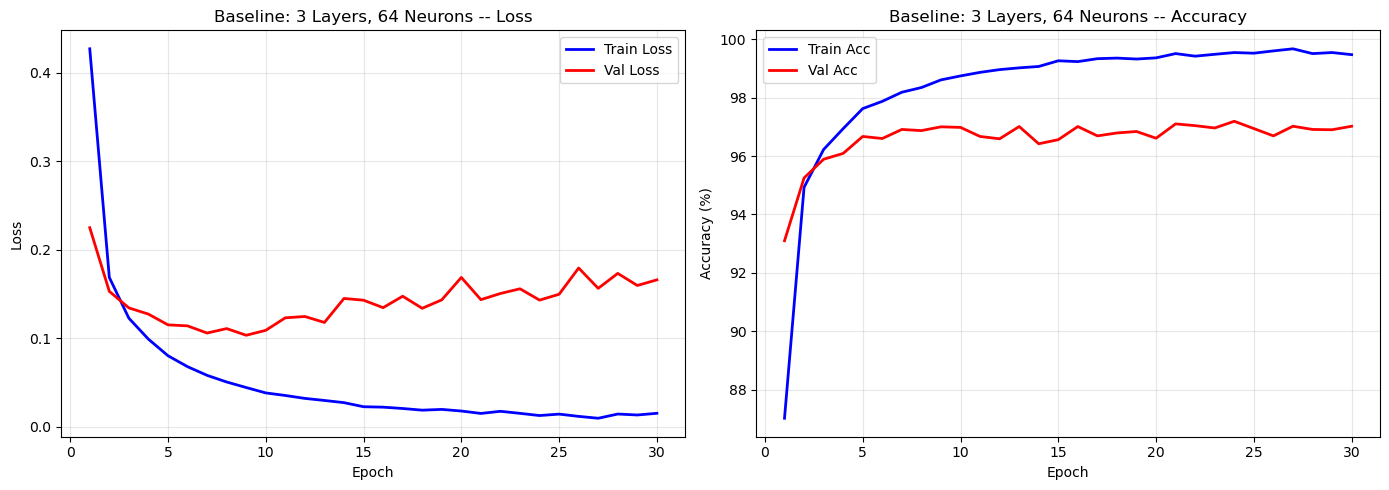

Epoch   1/30 | Train Loss: 0.3497 Acc: 89.52% | Val Loss: 0.1762 Acc: 94.62%
Epoch   5/30 | Train Loss: 0.0566 Acc: 98.17% | Val Loss: 0.0889 Acc: 97.50%
Epoch  10/30 | Train Loss: 0.0281 Acc: 98.99% | Val Loss: 0.1061 Acc: 97.24%
Epoch  15/30 | Train Loss: 0.0166 Acc: 99.41% | Val Loss: 0.1134 Acc: 97.67%
Epoch  20/30 | Train Loss: 0.0118 Acc: 99.63% | Val Loss: 0.1079 Acc: 98.02%
Epoch  25/30 | Train Loss: 0.0117 Acc: 99.62% | Val Loss: 0.1376 Acc: 97.54%
Epoch  30/30 | Train Loss: 0.0075 Acc: 99.75% | Val Loss: 0.1603 Acc: 97.14%

--- Baseline 3x128 ---
Parameters: 134,794
Best Val Acc: 98.02% (epoch 20)
Test Acc:     97.97%
Overfit Gap:  1.73%


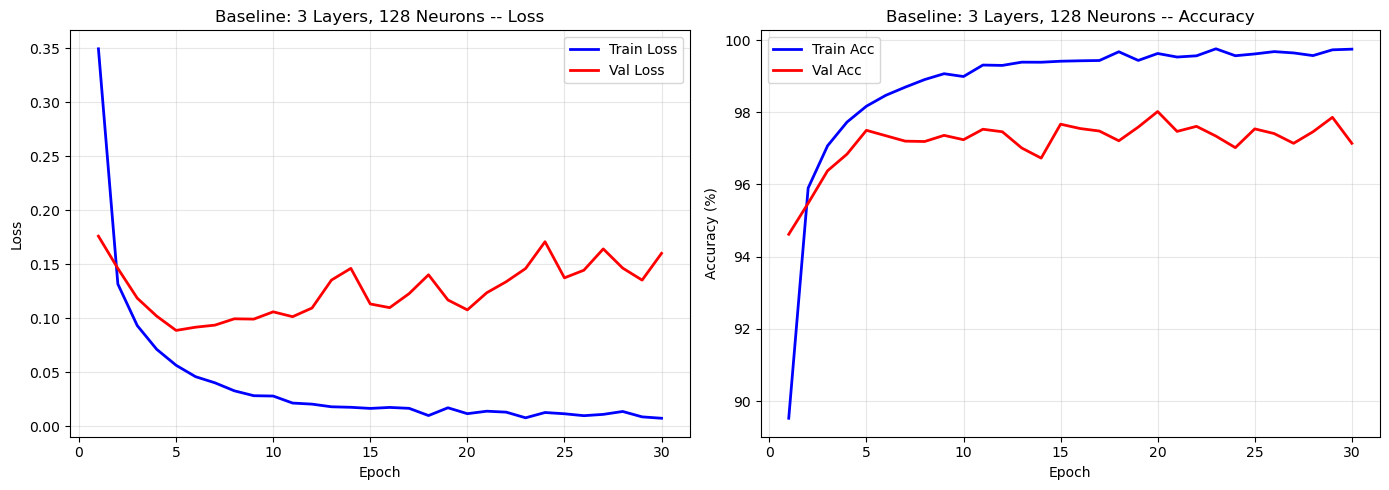

Epoch   1/30 | Train Loss: 0.2879 Acc: 91.19% | Val Loss: 0.1466 Acc: 95.71%
Epoch   5/30 | Train Loss: 0.0438 Acc: 98.56% | Val Loss: 0.1020 Acc: 97.08%
Epoch  10/30 | Train Loss: 0.0191 Acc: 99.35% | Val Loss: 0.1201 Acc: 97.19%
Epoch  15/30 | Train Loss: 0.0115 Acc: 99.63% | Val Loss: 0.1013 Acc: 98.07%
Epoch  20/30 | Train Loss: 0.0101 Acc: 99.67% | Val Loss: 0.1259 Acc: 97.58%
Epoch  25/30 | Train Loss: 0.0068 Acc: 99.81% | Val Loss: 0.1441 Acc: 97.59%
Epoch  30/30 | Train Loss: 0.0065 Acc: 99.81% | Val Loss: 0.1479 Acc: 97.51%

--- Baseline 3x256 ---
Parameters: 335,114
Best Val Acc: 98.18% (epoch 26)
Test Acc:     98.26%
Overfit Gap:  1.63%


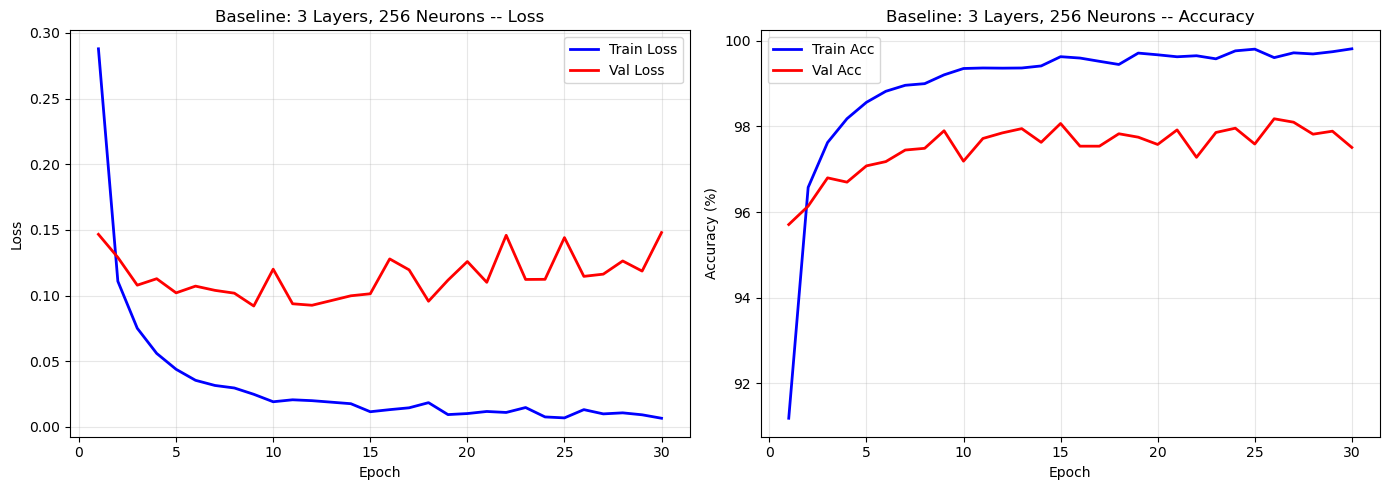

Epoch   1/30 | Train Loss: 0.2528 Acc: 92.21% | Val Loss: 0.1380 Acc: 95.63%
Epoch   5/30 | Train Loss: 0.0412 Acc: 98.66% | Val Loss: 0.0886 Acc: 97.41%
Epoch  10/30 | Train Loss: 0.0229 Acc: 99.25% | Val Loss: 0.1197 Acc: 97.43%
Epoch  15/30 | Train Loss: 0.0162 Acc: 99.49% | Val Loss: 0.1111 Acc: 97.81%
Epoch  20/30 | Train Loss: 0.0123 Acc: 99.64% | Val Loss: 0.1200 Acc: 97.64%
Epoch  25/30 | Train Loss: 0.0117 Acc: 99.69% | Val Loss: 0.1711 Acc: 97.65%
Epoch  30/30 | Train Loss: 0.0092 Acc: 99.78% | Val Loss: 0.1310 Acc: 98.08%

--- Baseline 3x512 ---
Parameters: 932,362
Best Val Acc: 98.08% (epoch 30)
Test Acc:     98.23%
Overfit Gap:  1.70%


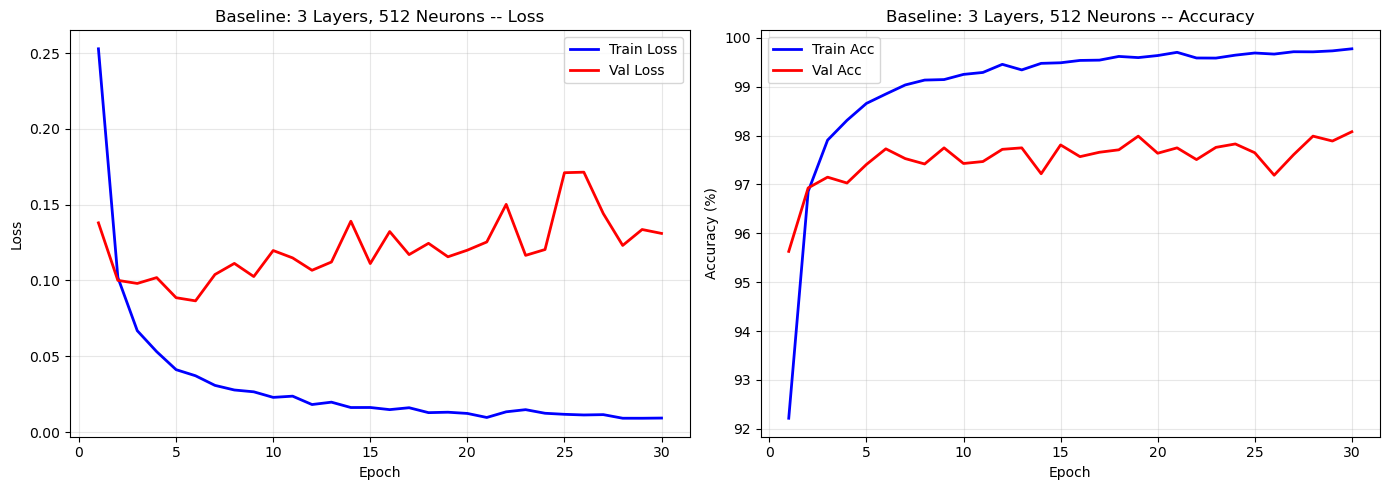

Epoch   1/30 | Train Loss: 0.2277 Acc: 93.01% | Val Loss: 0.1754 Acc: 94.94%
Epoch   5/30 | Train Loss: 0.0467 Acc: 98.57% | Val Loss: 0.1050 Acc: 97.51%
Epoch  10/30 | Train Loss: 0.0226 Acc: 99.32% | Val Loss: 0.1144 Acc: 97.88%
Epoch  15/30 | Train Loss: 0.0190 Acc: 99.45% | Val Loss: 0.1236 Acc: 97.66%
Epoch  20/30 | Train Loss: 0.0146 Acc: 99.60% | Val Loss: 0.1185 Acc: 97.82%
Epoch  25/30 | Train Loss: 0.0132 Acc: 99.65% | Val Loss: 0.1431 Acc: 97.96%
Epoch  30/30 | Train Loss: 0.0099 Acc: 99.76% | Val Loss: 0.1781 Acc: 97.63%

--- Baseline 3x1028 ---
Parameters: 2,932,894
Best Val Acc: 98.14% (epoch 18)
Test Acc:     98.24%
Overfit Gap:  1.62%


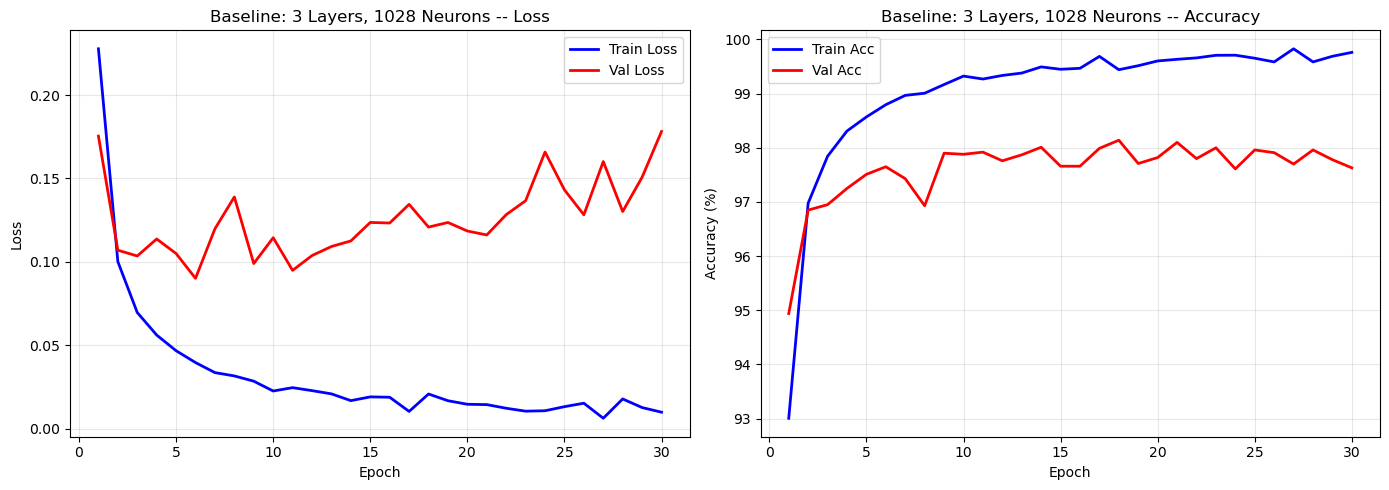

In [ ]:
# Repeat with num_layers=3 and varying hidden_size
model = MLP(hidden_size=64, num_layers=3)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 3x64', model, history, best_val, best_ep, num_layers=3, hidden_size=64)
plot_learning_curves(history, title='Baseline: 3 Layers, 64 Neurons')

model = MLP(hidden_size=128, num_layers=3)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 3x128', model, history, best_val, best_ep, num_layers=3, hidden_size=128)
plot_learning_curves(history, title='Baseline: 3 Layers, 128 Neurons')

model = MLP(hidden_size=256, num_layers=3)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 3x256', model, history, best_val, best_ep, num_layers=3, hidden_size=256)
plot_learning_curves(history, title='Baseline: 3 Layers, 256 Neurons')

model = MLP(hidden_size=512, num_layers=3)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 3x512', model, history, best_val, best_ep, num_layers=3, hidden_size=512)
plot_learning_curves(history, title='Baseline: 3 Layers, 512 Neurons')

model = MLP(hidden_size=1024, num_layers=3)
history, best_val, best_ep = train_model(model, train_loader, val_loader, num_epochs=30)
record_result('Baseline 3x1024', model, history, best_val, best_ep, num_layers=3, hidden_size=1024)
plot_learning_curves(history, title='Baseline: 3 Layers, 1024 Neurons')

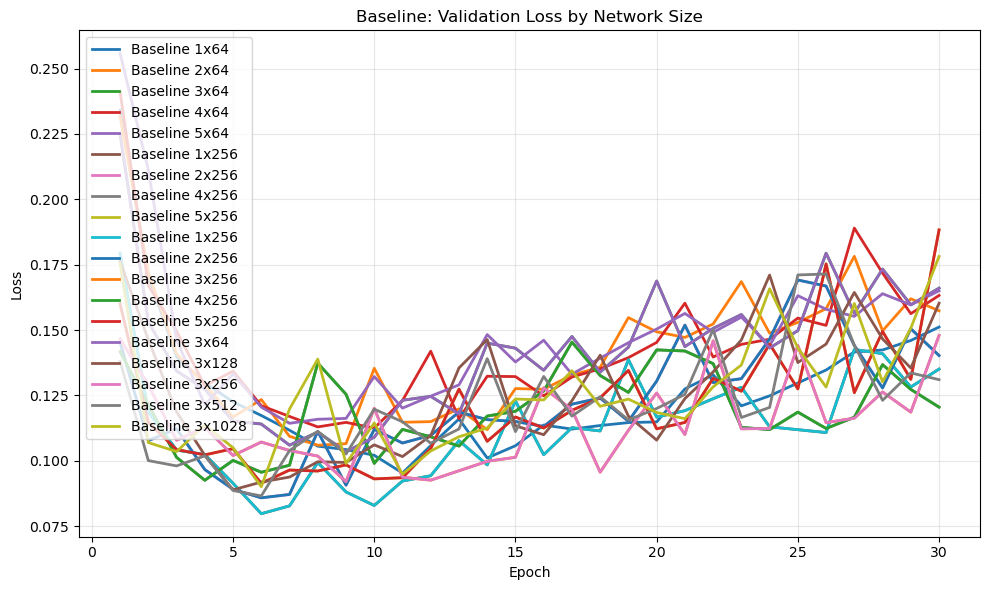

In [38]:
# TODO: Visualize your baseline results
# - Compare learning curves of small vs. large networks
# - Create the overfitting heatmap (if you varied both layers and sizes)
# - Identify the "overfitting threshold": at what size does the gap become significant?
#
# Example:
# baseline_names = ['Baseline 1x128', 'Baseline 2x256', 'Baseline 4x512']
# baseline_histories = [all_histories[n] for n in baseline_names]
# plot_comparison_curves(baseline_histories, baseline_names, metric='val_loss',
#                        title='Baseline: Validation Loss by Network Size')

# Your code here:

baseline_names = ['Baseline 1x64', 'Baseline 2x64', 'Baseline 3x64', 'Baseline 4x64', 'Baseline 5x64',
                  'Baseline 1x256', 'Baseline 2x256',    'Baseline 4x256', 'Baseline 5x256',
                  'Baseline 1x256', 'Baseline 2x256', 'Baseline 3x256', 'Baseline 4x256', 'Baseline 5x256',
                  'Baseline 3x64', 'Baseline 3x128', 'Baseline 3x256', 'Baseline 3x512', 'Baseline 3x1028']
baseline_histories = [all_histories[n] for n in baseline_names]
plot_comparison_curves(baseline_histories, baseline_names, metric='val_loss', title='Baseline: Validation Loss by Network Size')


---

## 8. Experiment 2: L2 Regularization (Weight Decay)

L2 regularization adds a penalty proportional to the **squared magnitude** of the weights.  
In PyTorch, this is implemented via the `weight_decay` parameter of the optimizer.

In [14]:
# TODO: Experiment with L2 regularization (weight_decay in optimizer).
# Pick one or two network sizes that showed overfitting in the baseline.
# Vary weight_decay: 1e-5, 1e-4, 1e-3, 1e-2
#
# Example:
# for wd in [1e-5, 1e-4, 1e-3, 1e-2]:
#     model = MLP(hidden_size=256, num_layers=2)
#     history, best_val, best_ep = train_model(
#         model, train_loader, val_loader, num_epochs=30, weight_decay=wd
#     )
#     record_result(f'L2 wd={wd}', model, history, best_val, best_ep,
#                   num_layers=2, hidden_size=256, regularization=f'L2({wd})')

# Your code here:

for wd in [1e-5, 1e-4, 1e-3, 1e-2]:
    model = MLP(hidden_size=256, num_layers=2)
    history, best_val, best_ep = train_model(
        model, train_loader, val_loader, num_epochs=30, weight_decay=wd
    )
    record_result(f'L2 wd={wd}', model, history, best_val, best_ep,
                  num_layers=2, hidden_size=256, regularization=f'L2({wd})')

Epoch   1/30 | Train Loss: 0.2747 Acc: 91.85% | Val Loss: 0.1433 Acc: 95.59%
Epoch   5/30 | Train Loss: 0.0393 Acc: 98.76% | Val Loss: 0.0855 Acc: 97.58%
Epoch  10/30 | Train Loss: 0.0211 Acc: 99.25% | Val Loss: 0.0922 Acc: 97.73%
Epoch  15/30 | Train Loss: 0.0136 Acc: 99.52% | Val Loss: 0.1237 Acc: 97.29%
Epoch  20/30 | Train Loss: 0.0101 Acc: 99.66% | Val Loss: 0.1501 Acc: 97.27%
Epoch  25/30 | Train Loss: 0.0117 Acc: 99.64% | Val Loss: 0.1183 Acc: 97.82%
Epoch  30/30 | Train Loss: 0.0074 Acc: 99.76% | Val Loss: 0.1219 Acc: 97.77%

--- L2 wd=1e-05 ---
Parameters: 269,322
Best Val Acc: 98.08% (epoch 27)
Test Acc:     98.13%
Overfit Gap:  1.68%
Epoch   1/30 | Train Loss: 0.2827 Acc: 91.57% | Val Loss: 0.1581 Acc: 95.13%
Epoch   5/30 | Train Loss: 0.0422 Acc: 98.59% | Val Loss: 0.0939 Acc: 97.18%
Epoch  10/30 | Train Loss: 0.0188 Acc: 99.35% | Val Loss: 0.0994 Acc: 97.42%
Epoch  15/30 | Train Loss: 0.0142 Acc: 99.47% | Val Loss: 0.0945 Acc: 97.59%
Epoch  20/30 | Train Loss: 0.0110 Acc: 

---

## 9. Experiment 3: L1 Regularization

L1 regularization adds a penalty proportional to the **absolute value** of the weights.  
Unlike L2, it encourages **sparsity** (some weights become exactly zero).  
PyTorch does not have a built-in L1 option in the optimizer -- instead, we add it manually to the loss.  
The `train_one_epoch()` function already supports this via the `l1_lambda` parameter.

In [15]:
# TODO: Experiment with L1 regularization.
# Use the l1_lambda parameter in train_model().
# Vary l1_lambda: 1e-5, 1e-4, 1e-3, 1e-2
#
# Example:
# for l1 in [1e-5, 1e-4, 1e-3]:
#     model = MLP(hidden_size=256, num_layers=2)
#     history, best_val, best_ep = train_model(
#         model, train_loader, val_loader, num_epochs=30, l1_lambda=l1
#     )
#     record_result(f'L1 lambda={l1}', model, history, best_val, best_ep,
#                   num_layers=2, hidden_size=256, regularization=f'L1({l1})')
#
# Bonus: After training with L1, inspect how many weights are close to zero:
# weights = torch.cat([p.flatten() for p in model.parameters()])
# near_zero = (weights.abs() < 1e-3).sum().item()
# print(f'Weights near zero: {near_zero}/{len(weights)} ({100*near_zero/len(weights):.1f}%)')

# Your code here:

for l1 in [1e-5, 1e-4, 1e-3, 1e-2]:
    model = MLP(hidden_size=256, num_layers=2)
    history, best_val, best_ep = train_model(
        model, train_loader, val_loader, num_epochs=30, l1_lambda=l1
    )
    record_result(f'L1 lambda={l1}', model, history, best_val, best_ep,
                  num_layers=2, hidden_size=256, regularization=f'L1({l1})')
    
    # Inspect sparsity of weights
    weights = torch.cat([p.flatten() for p in model.parameters()])
    near_zero = (weights.abs() < 1e-3).sum().item()
    print(f'L1 lambda={l1}: Weights near zero: {near_zero}/{len(weights)} ({100*near_zero/len(weights):.1f}%)')

Epoch   1/30 | Train Loss: 0.3338 Acc: 91.91% | Val Loss: 0.1457 Acc: 95.45%
Epoch   5/30 | Train Loss: 0.1013 Acc: 98.59% | Val Loss: 0.0951 Acc: 97.07%
Epoch  10/30 | Train Loss: 0.0749 Acc: 99.33% | Val Loss: 0.0889 Acc: 97.58%
Epoch  15/30 | Train Loss: 0.0680 Acc: 99.43% | Val Loss: 0.0963 Acc: 97.59%
Epoch  20/30 | Train Loss: 0.0612 Acc: 99.57% | Val Loss: 0.1010 Acc: 97.82%
Epoch  25/30 | Train Loss: 0.0576 Acc: 99.58% | Val Loss: 0.0966 Acc: 97.70%
Epoch  30/30 | Train Loss: 0.0518 Acc: 99.72% | Val Loss: 0.1018 Acc: 97.77%

--- L1 lambda=1e-05 ---
Parameters: 269,322
Best Val Acc: 97.88% (epoch 17)
Test Acc:     97.94%
Overfit Gap:  1.84%
L1 lambda=1e-05: Weights near zero: 112742/269322 (41.9%)
Epoch   1/30 | Train Loss: 0.6613 Acc: 91.27% | Val Loss: 0.1996 Acc: 93.90%
Epoch   5/30 | Train Loss: 0.2268 Acc: 97.54% | Val Loss: 0.1015 Acc: 97.04%
Epoch  10/30 | Train Loss: 0.1688 Acc: 98.26% | Val Loss: 0.0855 Acc: 97.23%
Epoch  15/30 | Train Loss: 0.1498 Acc: 98.59% | Val Lo

---

## 10. Experiment 4: Dropout

Dropout randomly sets a fraction of neuron activations to zero during training.  
This prevents the network from relying on any single neuron, encouraging redundancy.  
The MLP class already supports Dropout via the `dropout_rate` parameter.

In [16]:
# TODO: Experiment with Dropout.
# Create models with different dropout_rate values: 0.1, 0.2, 0.3, 0.5
#
# Example:
# for dr in [0.1, 0.2, 0.3, 0.5]:
#     model = MLP(hidden_size=256, num_layers=2, dropout_rate=dr)
#     history, best_val, best_ep = train_model(
#         model, train_loader, val_loader, num_epochs=30
#     )
#     record_result(f'Dropout p={dr}', model, history, best_val, best_ep,
#                   num_layers=2, hidden_size=256, regularization=f'Dropout({dr})')

# Your code here:

for dr in [0.1, 0.2, 0.3, 0.5]:
    model = MLP(hidden_size=256, num_layers=2, dropout_rate=dr)
    history, best_val, best_ep = train_model(
        model, train_loader, val_loader, num_epochs=30
    )
    record_result(f'Dropout p={dr}', model, history, best_val, best_ep,
                  num_layers=2, hidden_size=256, regularization=f'Dropout({dr})')

Epoch   1/30 | Train Loss: 0.2943 Acc: 91.29% | Val Loss: 0.1647 Acc: 95.26%
Epoch   5/30 | Train Loss: 0.0513 Acc: 98.32% | Val Loss: 0.0972 Acc: 97.24%
Epoch  10/30 | Train Loss: 0.0260 Acc: 99.10% | Val Loss: 0.0932 Acc: 97.74%
Epoch  15/30 | Train Loss: 0.0239 Acc: 99.18% | Val Loss: 0.0944 Acc: 97.85%
Epoch  20/30 | Train Loss: 0.0164 Acc: 99.45% | Val Loss: 0.1106 Acc: 97.92%
Epoch  25/30 | Train Loss: 0.0158 Acc: 99.50% | Val Loss: 0.1051 Acc: 97.87%
Epoch  30/30 | Train Loss: 0.0136 Acc: 99.56% | Val Loss: 0.1218 Acc: 98.00%

--- Dropout p=0.1 ---
Parameters: 269,322
Best Val Acc: 98.09% (epoch 22)
Test Acc:     98.16%
Overfit Gap:  1.47%
Epoch   1/30 | Train Loss: 0.3153 Acc: 90.50% | Val Loss: 0.1736 Acc: 94.68%
Epoch   5/30 | Train Loss: 0.0696 Acc: 97.87% | Val Loss: 0.0844 Acc: 97.60%
Epoch  10/30 | Train Loss: 0.0423 Acc: 98.65% | Val Loss: 0.0859 Acc: 97.55%
Epoch  15/30 | Train Loss: 0.0307 Acc: 98.94% | Val Loss: 0.0887 Acc: 97.86%
Epoch  20/30 | Train Loss: 0.0293 Acc

---

## 11. Experiment 5: Batch Normalization

Batch Normalization normalizes the input to each layer, which stabilizes training and  
has a mild regularizing effect. The MLP class supports it via `use_batchnorm=True`.

Note: There is a known interaction between Batch Normalization and Dropout.  
BN relies on batch statistics during training, and Dropout changes the effective  
distribution. Discuss whether combining them helps or hurts.

In [17]:
# TODO: Experiment with Batch Normalization.
# Compare the same architectures with and without BN.
#
# Example:
# model = MLP(hidden_size=256, num_layers=2, use_batchnorm=True)
# history, best_val, best_ep = train_model(
#     model, train_loader, val_loader, num_epochs=30
# )
# record_result('BatchNorm 2x256', model, history, best_val, best_ep,
#               num_layers=2, hidden_size=256, regularization='BatchNorm')

# Your code here:

model = MLP(hidden_size=256, num_layers=2, use_batchnorm=True)
history, best_val, best_ep = train_model(
    model, train_loader, val_loader, num_epochs=30
)
record_result('BatchNorm 2x256', model, history, best_val, best_ep,
              num_layers=2, hidden_size=256, regularization='BatchNorm')

Epoch   1/30 | Train Loss: 0.2143 Acc: 94.02% | Val Loss: 0.1120 Acc: 96.49%
Epoch   5/30 | Train Loss: 0.0281 Acc: 99.09% | Val Loss: 0.0728 Acc: 97.72%
Epoch  10/30 | Train Loss: 0.0128 Acc: 99.54% | Val Loss: 0.0821 Acc: 97.91%
Epoch  15/30 | Train Loss: 0.0081 Acc: 99.72% | Val Loss: 0.0917 Acc: 97.94%
Epoch  20/30 | Train Loss: 0.0082 Acc: 99.71% | Val Loss: 0.0929 Acc: 98.03%
Epoch  25/30 | Train Loss: 0.0070 Acc: 99.77% | Val Loss: 0.0906 Acc: 98.01%
Epoch  30/30 | Train Loss: 0.0056 Acc: 99.84% | Val Loss: 0.0960 Acc: 97.96%

--- BatchNorm 2x256 ---
Parameters: 270,346
Best Val Acc: 98.15% (epoch 27)
Test Acc:     98.32%
Overfit Gap:  1.69%


98.32

---

## 12. Experiment 6: Early Stopping

Early Stopping monitors the validation loss/accuracy and stops training when it stops  
improving. This prevents the model from overfitting by training for too many epochs.  
The `train_model()` function supports this via `early_stopping_patience`.

In [18]:
# TODO: Experiment with Early Stopping.
# Use a larger num_epochs (e.g., 50) and let early stopping decide when to stop.
# Vary patience: 3, 5, 10
#
# Example:
# for patience in [3, 5, 10]:
#     model = MLP(hidden_size=256, num_layers=2)
#     history, best_val, best_ep = train_model(
#         model, train_loader, val_loader, num_epochs=50,
#         early_stopping_patience=patience
#     )
#     record_result(f'EarlyStop p={patience}', model, history, best_val, best_ep,
#                   num_layers=2, hidden_size=256, regularization=f'EarlyStop({patience})')

# Your code here:

for patience in [3, 5, 10]:
    model = MLP(hidden_size=256, num_layers=2)
    history, best_val, best_ep = train_model(
        model, train_loader, val_loader, num_epochs=50,
        early_stopping_patience=patience
    )
    record_result(f'EarlyStop p={patience}', model, history, best_val, best_ep,
                  num_layers=2, hidden_size=256, regularization=f'EarlyStop({patience})')

Epoch   1/50 | Train Loss: 0.2784 Acc: 91.60% | Val Loss: 0.1532 Acc: 95.28%
Epoch   5/50 | Train Loss: 0.0404 Acc: 98.71% | Val Loss: 0.0973 Acc: 97.08%
Early stopping at epoch 9 (best val acc: 97.59% at epoch 6)

--- EarlyStop p=3 ---
Parameters: 269,322
Best Val Acc: 97.59% (epoch 6)
Test Acc:     97.56%
Overfit Gap:  1.68%
Epoch   1/50 | Train Loss: 0.2763 Acc: 91.61% | Val Loss: 0.1554 Acc: 95.14%
Epoch   5/50 | Train Loss: 0.0401 Acc: 98.72% | Val Loss: 0.0837 Acc: 97.52%
Epoch  10/50 | Train Loss: 0.0202 Acc: 99.31% | Val Loss: 0.1085 Acc: 97.51%
Epoch  15/50 | Train Loss: 0.0110 Acc: 99.65% | Val Loss: 0.1159 Acc: 97.72%
Epoch  20/50 | Train Loss: 0.0098 Acc: 99.68% | Val Loss: 0.1319 Acc: 97.59%
Epoch  25/50 | Train Loss: 0.0111 Acc: 99.67% | Val Loss: 0.1578 Acc: 97.51%
Early stopping at epoch 27 (best val acc: 98.00% at epoch 22)

--- EarlyStop p=5 ---
Parameters: 269,322
Best Val Acc: 98.00% (epoch 22)
Test Acc:     98.18%
Overfit Gap:  1.80%
Epoch   1/50 | Train Loss: 0.27

---

## 13. Experiment 7: Combining Techniques

Real-world models often combine multiple regularization techniques.  
Investigate whether combinations outperform individual techniques.

In [19]:
# TODO: Combine regularization techniques.
# Try at least 2-3 combinations on your largest network:
#   - L2 + Dropout
#   - BatchNorm + Dropout
#   - L2 + Dropout + Early Stopping
#   - BatchNorm + L2
#
# Example:
# model = MLP(hidden_size=512, num_layers=4, dropout_rate=0.3, use_batchnorm=True)
# history, best_val, best_ep = train_model(
#     model, train_loader, val_loader, num_epochs=50,
#     weight_decay=1e-4, early_stopping_patience=5
# )
# record_result('BN+Dropout+L2+ES 4x512', model, history, best_val, best_ep,
#               num_layers=4, hidden_size=512,
#               regularization='BN+Dropout(0.3)+L2(1e-4)+ES(5)')

# Your code here:

model = MLP(hidden_size=512, num_layers=4, dropout_rate=0.3, use_batchnorm=True)
history, best_val, best_ep = train_model(
    model, train_loader, val_loader, num_epochs=50,
    weight_decay=1e-4, early_stopping_patience=5
)
record_result('BN+Dropout+L2+ES 4x512', model, history, best_val, best_ep,
              num_layers=4, hidden_size=512,
              regularization='BN+Dropout(0.3)+L2(1e-4)+ES(5)')

Epoch   1/50 | Train Loss: 0.2819 Acc: 91.39% | Val Loss: 0.1264 Acc: 96.14%
Epoch   5/50 | Train Loss: 0.0865 Acc: 97.31% | Val Loss: 0.0761 Acc: 97.73%
Epoch  10/50 | Train Loss: 0.0641 Acc: 97.97% | Val Loss: 0.0697 Acc: 97.78%
Epoch  15/50 | Train Loss: 0.0533 Acc: 98.28% | Val Loss: 0.0688 Acc: 97.96%
Early stopping at epoch 18 (best val acc: 98.06% at epoch 13)

--- BN+Dropout+L2+ES 4x512 ---
Parameters: 1,199,114
Best Val Acc: 98.06% (epoch 13)
Test Acc:     98.08%
Overfit Gap:  0.28%


98.08

---

## 14. Results Summary and Comparison

Bring all results together for a comprehensive comparison.

In [20]:
# Display full results table
print('\n' + '=' * 80)
print('FULL RESULTS TABLE')
print('=' * 80)
display_cols = ['experiment', 'num_layers', 'hidden_size', 'regularization',
                'num_params', 'best_val_acc', 'test_acc', 'overfitting_gap', 'best_epoch']
print(results[display_cols].to_string(index=False))


FULL RESULTS TABLE
            experiment num_layers hidden_size                 regularization num_params  best_val_acc  test_acc  overfitting_gap best_epoch
        Baseline 1x128          1         128                           None     101770         97.50     97.90            2.210         17
         Baseline 1x64          1          64                           None      50890         97.21     97.23            2.542         22
         Baseline 2x64          2          64                           None      55050         97.24     97.75            2.316         25
         Baseline 4x64          4          64                           None      63370         97.46     97.69            2.088         20
        Baseline 1x256          1         256                           None     203530         97.81     97.99            2.054         26
        Baseline 2x256          2         256                           None     269322         97.93     98.20            1.686         22


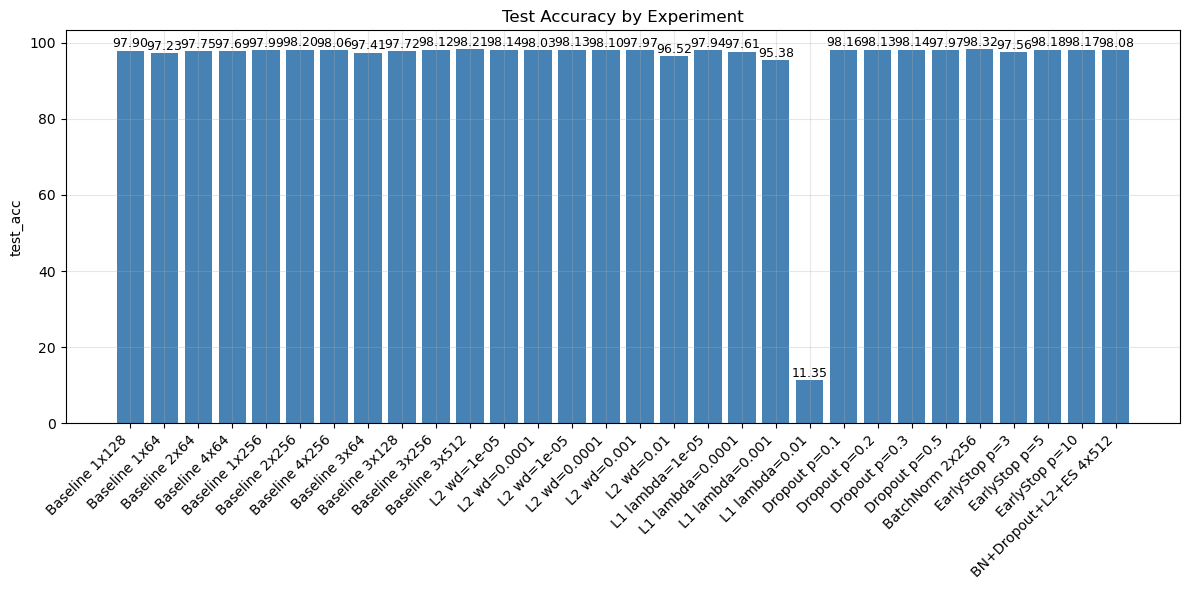

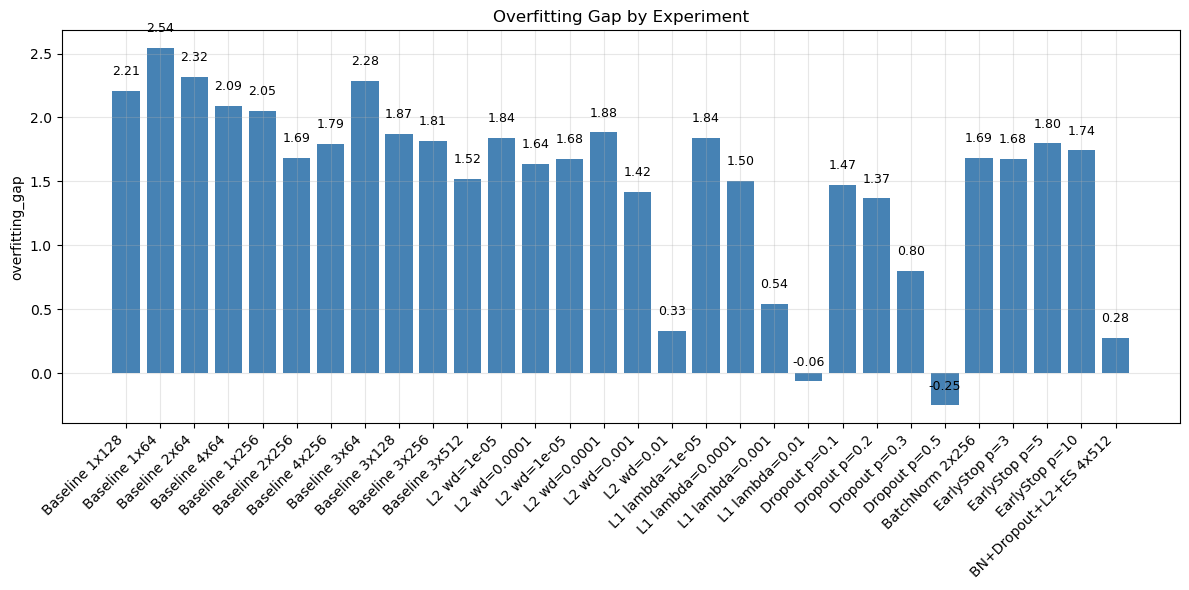

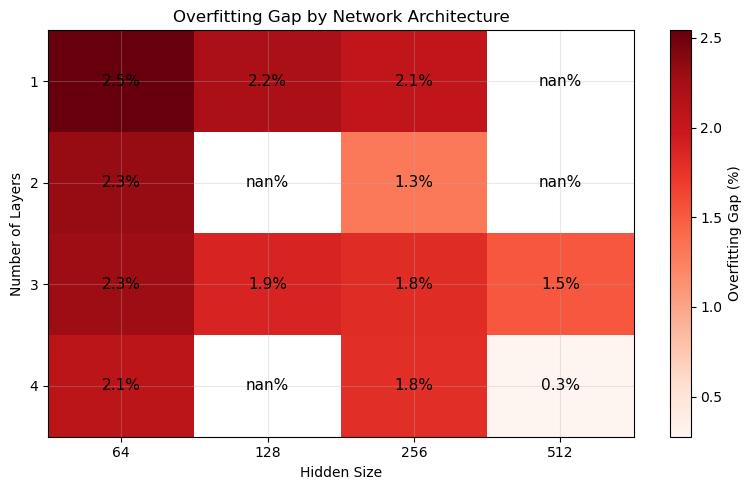

In [21]:
# TODO: Create final comparison visualizations for your report.
# Ideas:
#   1. Bar chart of test accuracy across all experiments
#   2. Overfitting gap comparison
#   3. Side-by-side learning curves for the most interesting comparisons
#   4. Heatmap of overfitting by architecture (baseline only)
#
# Example:
# plot_results_bar(results, metric='test_acc', title='Test Accuracy by Experiment')
# plot_results_bar(results, metric='overfitting_gap', title='Overfitting Gap by Experiment')

# Your code here:


plot_results_bar(results, metric='test_acc', title='Test Accuracy by Experiment')
plot_results_bar(results, metric='overfitting_gap', title='Overfitting Gap by Experiment')
plot_overfitting_heatmap(results)

In [22]:
# Save results to CSV for use in the report
results.to_csv('rq1_results.csv', index=False)
print('Results saved to rq1_results.csv')

Results saved to rq1_results.csv


---

## 15. Key Findings

Summarize your main observations here (these will feed into your report).

**TODO:** Write a brief summary of your findings:

1. **At what network size does overfitting become a problem?**  
   Overfitting ist bereits bei den kleineren Baselines sichtbar, wird aber ab etwa 2x256 bzw. 3x256 klar relevant. Das sieht man daran, dass die Trainingsgenauigkeit fast immer deutlich über der Validierungsgenauigkeit liegt. Besonders kleineren Modellen wie 1x64 oder 1x128 fehlt zwar Kapazität, sie zeigen aber trotzdem schon einen Overfitting-Gap von über 2 Prozentpunkten. Bei größeren Modellen wie 3x512 steigt die Leistung weiter, aber ohne Regularisierung bleibt das Risiko von Overfitting klar erkennbar.

2. **Which regularization technique was most effective?**  
   In den bisherigen Ergebnissen war Batch Normalization insgesamt am effektivsten. Das Modell BatchNorm 2x256 erreicht mit 98.32 % Test Accuracy den besten Wert aller regulierten Modelle. Auch Dropout, vor allem mit 0.3, war sehr stark, weil es den Overfitting-Gap deutlich reduziert hat. L2-Regularisierung war nur in kleinen Dosen hilfreich, während L1 bei zu großen Werten die Leistung stark verschlechtert hat.

3. **Did combining techniques help?**  
   Ja, aber nicht automatisch in Form der besten Testgenauigkeit. Die Kombination BN + Dropout + L2 + Early Stopping hat den Overfitting-Gap extrem stark reduziert und damit die stabilste Generalisierung gezeigt. Die Testgenauigkeit war jedoch nicht höher als bei reinem BatchNorm. Das deutet darauf hin, dass Kombinationen vor allem helfen, Overfitting robuster zu kontrollieren, aber nicht zwingend den absoluten Bestwert bei der Accuracy liefern.

4. **What surprised you?**  
   Überraschend war, dass stärkere Regularisierung nicht automatisch besser war. Zum Beispiel hat L1 mit 0.01 das Modell praktisch unbrauchbar gemacht, und auch sehr starkes L2 (0.01) hat die Leistung klar verschlechtert. Außerdem war interessant, dass BatchNorm hier nicht nur das Training stabilisiert hat, sondern auch die beste Testgenauigkeit erreicht hat, obwohl man oft eher Dropout oder Early Stopping als Hauptmittel gegen Overfitting erwartet.